In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
    
    
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [29]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[1:2] + ["gold"]
color_list2 = palette_tab10[0:1]  + palette_tab10[9:10]

In [17]:
odir = "ps_data"
with open(f"{odir}/ics/test5.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 1.976102912


In [3]:

odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.38519438706473


In [66]:
from nbodykit import cosmology as cosmology_nbody
iend = 200
cosmo1 = cosmology_nbody.Planck15
z=1.5
Plin = cosmology_nbody.LinearPower(cosmo1, redshift=z, transfer='EisensteinHu') 
Pnl = cosmology_nbody.power.halofit.HalofitPower(cosmo1, redshift=z) 

#k_analytical = 10**np.arange(-1.6,0,0.05)
#k_colossus = 10**np.arange(-3,0,0.02)
ks = Pk_gal10['k'][:iend]
coef = ks**3 / (2 * np.pi **2)
Pk_linear = Plin(ks)
normed_Pk_matter_lin = coef * Pk_linear 
Pk_nonlinear = Pnl(ks)
normed_Pk_matter_nl = coef * Pk_nonlinear 

In [70]:
Plin_ic = cosmology_nbody.LinearPower(cosmo1, redshift=127, transfer='EisensteinHu') 
ks = Pk_gal10['k'][:iend]
coef = ks**3 / (2 * np.pi **2)
Pk_linear_ic = Plin_ic(ks)

In [51]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')

In [54]:
D15 = cosmo.growthFactorUnnormalized(z)
D127 = cosmo.growthFactorUnnormalized(127)

In [64]:
growth_factor = (D15/D127)**2
print(growth_factor)

2373.7995200129235


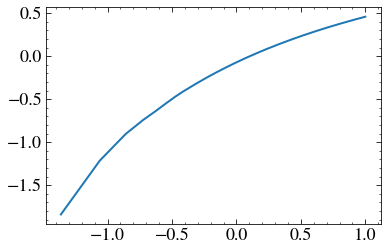

In [21]:
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin), label="linear")

In [8]:
Pk_ic["k"]

array([], dtype=float64)

In [9]:
Pk_ic["power"]

array([], dtype=complex128)

In [16]:
Pk_ic.attrs

{'Nmesh': array([2247, 2247, 2247]),
 'BoxSize': array([204.90880783, 204.90880783, 204.90880783]),
 'Lx': 204.90880782918148,
 'Ly': 204.90880782918148,
 'Lz': 204.90880782918148,
 'volume': 8603633.060653092,
 'mode': '1d',
 'los': [0, 0, 1],
 'Nmu': 1,
 'poles': [],
 'dk': 0.05,
 'kmin': 0.01,
 'kmax': None,
 'N1': 244140625,
 'N2': 244140625,
 'shotnoise': 1.9734669369203637}

shotnoise:  130.38519438706473
shotnoise:  1.976102912


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1474: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


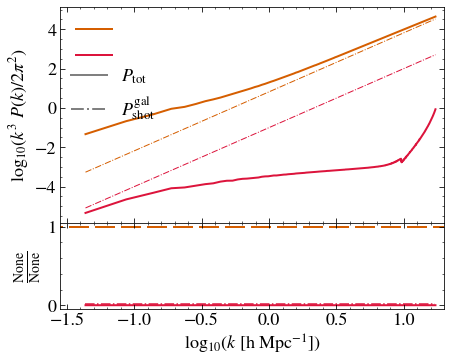

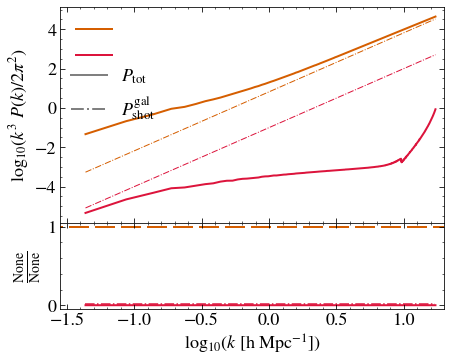

In [42]:
ps.compare_ps_plot([Pk_gal10, Pk_ic])

shotnoise:  1.976102912


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1474: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


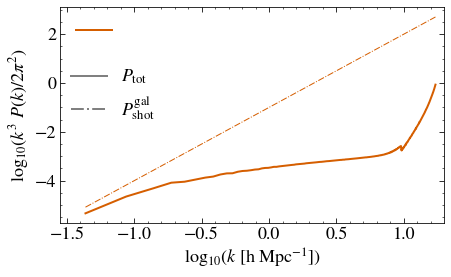

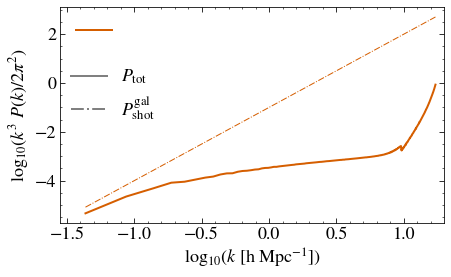

In [18]:
ps.compare_ps_plot([Pk_ic])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


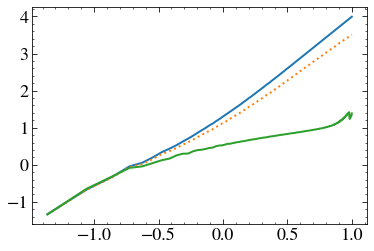

In [26]:
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total")
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10(coef * Pk_ic["power"][:iend]*1e4), label="TNG total")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


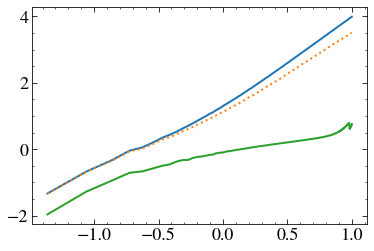

In [62]:
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total")
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10(coef * Pk_ic["power"][:iend]*growth_factor), label="TNG total")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


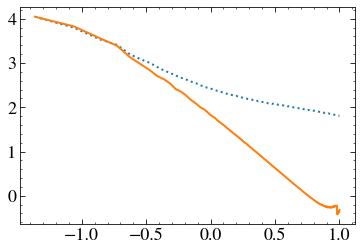

In [45]:
plt.plot(np.log10(ks), np.log10((Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10( Pk_ic["power"][:iend]*1e4), label="TNG total")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.9, 2.0)

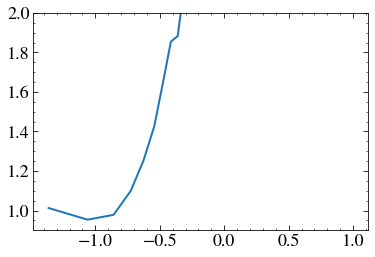

In [47]:
plt.plot(np.log10(ks),Pk_gal10["power"][:iend]/(Pk_ic["power"][:iend]*1e4))
#plt.ylim(0.9,1.1)
plt.ylim(0.9,2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


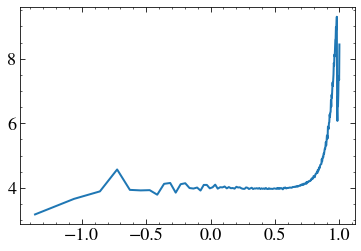

In [41]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend]*1e4)/Pk_linear)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


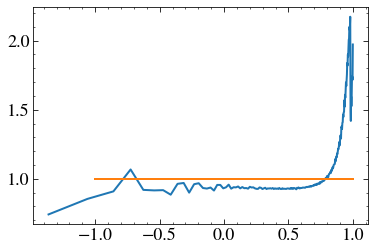

In [72]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_linear_ic)
plt.plot([-1,1], [1,1])

In [30]:
color_list1 = palette_tab10[3:4] + ["gold"]

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


NameError: name 'pkgal2_ratio' is not defined

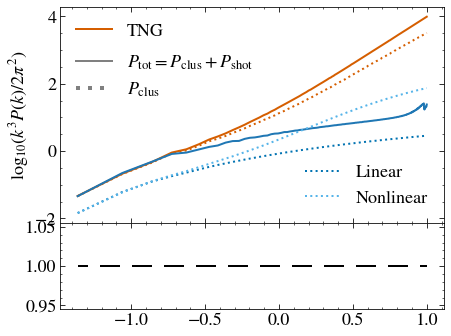

In [31]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * Pk_sum10["power"][:iend]), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])

plt.plot(np.log10(ks), np.log10(coef * Pk_ic["power"][:iend]*1e4), label="TNG total")

plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin), label="linear x 4", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["TNG"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False)
ax.add_artist(first_legend)
label_list = ["Linear", "Nonlinear"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
    
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,0))
ax.add_artist(second_legend)

color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot} = P_{\rm clus} + P_{\rm shot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}}$", linewidth=4)
leg_list = [total_ps_leg, shotnoise_subtracted_ps_leg]
ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([np.log10(ks[0]),np.log10(ks[-1])], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")

plt.plot(np.log10(ks), coef * Pk_gal10["power"][:iend]/(pkgal2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks),coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/(pkgal2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks),(Pk_gal10["power"][:iend]-2*Pk_sum10.attrs["shotnoise"])/(pkgal3_ratio*Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color="red")
plt.plot(np.log10(ks),(Pk2["power"][:iend]-Pk2.attrs["shotnoise"])/(5*Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color="green")


#plt.plot(np.log10(ks),np.sqrt((Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pkgal2_ratio*Pk_linear)), linestyle="dotted", label="TNG clustering (gal)", color="purple")
#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
plt.plot(np.log10(ks), normed_Pk_matter_nl/normed_Pk_matter_lin, label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.plot(np.log10(ks), (Pk1["power"][:iend]-Pk1.attrs["shotnoise"])/(pkgal3_ratio*Pk_linear))

plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
plt.ylim(0.7,2)
plt.ylabel("$C \cdot P/P_{linear}$")
#plt.savefig("figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")

shotnoise:  1.976102912


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1474: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


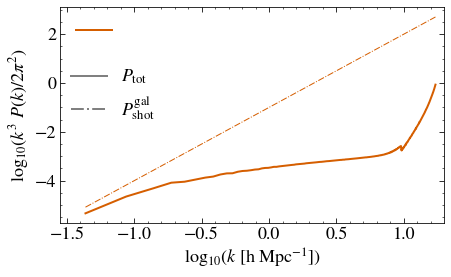

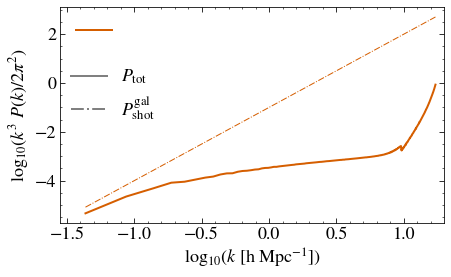

In [23]:
ps.compare_ps_plot([Pk_ic])
#plt.ylim(0,0.05)

shotnoise:  1.976102912
shotnoise:  130.38519438706473


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1474: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


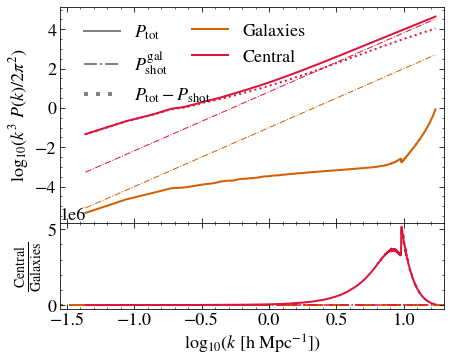

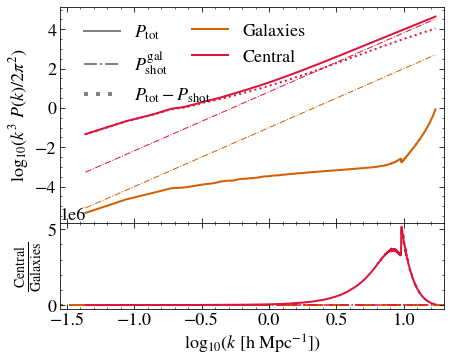

In [19]:
ps.compare_ps_plot([Pk_ic, Pk_gal10], labels=["Galaxies", "Central"], ratio_ylabel_list=["Galaxies","Central"], bbox_to_anchor_grey=(0.02,1), bbox_to_anchor_color=(0.3,1), shotnoise_subtracted_ps=True)
#plt.savefig("figures/cent_vs_gal.pdf", format="pdf", bbox_inches="tight")
#plt.ylim(0.5,10)